In [10]:
import os
import metapub
os.environ["NCBI_API_KEY"] = "70faf5cc42501a814dcc4bdb1862acaf3909"
metapub.config.NCBI_API_KEY = os.environ["NCBI_API_KEY"]

API_KEY = "70faf5cc42501a814dcc4bdb1862acaf3909"


import os
import requests
import logging
import time
from dateutil.relativedelta import relativedelta
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
import csv
import pandas as pd 
import numpy as np 
from tqdm.notebook import tqdm
from Bio import Entrez
from eutils import EutilsNCBIError, EutilsRequestError
from metapub import PubMedFetcher, pubmedcentral
from datetime import datetime
from tqdm.auto import tqdm
#Import DR module from Functions folder
from Functions import DataRetrieval as DR

import urllib
import json

from typing import List, Dict, Optional, Tuple
import xml.etree.ElementTree as ET
import random  

In [6]:
help("metapub.crossref")

Help on module metapub.crossref in metapub:

NAME
    metapub.crossref - # -*- coding: utf-8 -*-

CLASSES
    builtins.object
        CrossRefWork
    metapub.base.Borg(builtins.object)
        CrossRefFetcher
    
    class CrossRefFetcher(metapub.base.Borg)
     |  CrossRefFetcher(**kwargs)
     |  
     |  Valid field queries for this route are: affiliation, degree, event-acronym, bibliographic, container-title, publisher-name, author, event-theme, standards-body-acronym, chair, event-location, translator, funder-name, event-name, publisher-location, title, standards-body-name, contributor, editor, event-sponsor
     |  
     |  Method resolution order:
     |      CrossRefFetcher
     |      metapub.base.Borg
     |      builtins.object
     |  
     |  Methods defined here:
     |  
     |  __init__(self, **kwargs)
     |      Initialize self.  See help(type(self)) for accurate signature.
     |  
     |  article_by_doi(self, doi)
     |      Returns a CrossRefWork object loaded b

In [8]:
O = '''("english"[Language] 
NOT "book"[pt]
NOT "book chapter"[pt]
NOT "Case Reports"[Publication Type]
NOT "meta-analysis"[Publication Type] 
NOT "review"[Publication Type] 
NOT "retracted publication"[Publication Type] 
NOT "retraction of publication"[Publication Type] 
NOT "published erratum"[Publication Type] 
NOT "controlled clinical trial"[Publication Type] 
NOT "clinical study"[Publication Type] 
NOT "clinical trial"[Publication Type] 
NOT "clinical trial protocol"[Publication Type] 
NOT "clinical trial, phase i"[Publication Type] 
NOT "clinical trial, phase ii"[Publication Type] 
NOT "clinical trial, phase iii"[Publication Type] 
NOT "clinical trial, phase iv"[Publication Type] 
NOT "clinical trial, veterinary"[Publication Type])'''

A1 = '''"nucleoproteins"[MeSH Terms] 
OR "protein interaction mapping"[MeSH Terms] OR ("nucleoprotein"[All Fields] 
OR "nucleoproteins"[All Fields] 
OR "multiprotein"[All Fields] 
OR "multiproteins"[All Fields] 
OR "proteins"[MeSH Terms] 
OR "protein"[All Fields] 
OR "proteins"[All Fields] 
OR "enzyme"[All Fields]) 
AND 
("interact"[All Fields] 
OR "interacted"[All Fields] 
OR "interacting"[All Fields] 
OR "interaction"[All Fields] 
OR "interactions"[All Fields] 
OR "interactivity"[All Fields] 
OR "interacts"[All Fields]) OR ("protein interaction"[All Fields] 
OR "protein interactions"[All Fields] 
OR "interacting protein"[All Fields] 
OR "interacting proteins"[All Fields] OR "multiprotein complexes"[MeSH Terms]) OR
("nucleoprotein"[All Fields] 
OR "nucleoproteins"[All Fields] 
OR "multiprotein"[All Fields] 
OR "multiproteins"[All Fields] 
OR "proteins"[MeSH Terms] 
OR "protein"[All Fields] 
OR "proteins"[All Fields] 
OR "enzyme"[All Fields]) 
AND 
("complex"[All Fields] 
OR "complexes"[All Fields] 
OR "heteromer"[All Fields] 
OR "heteromers"[All Fields] 
OR "homomer"[All Fields] 
OR "homomers"[All Fields] 
OR "heteromeric"[All Fields] 
OR "homomeric"[All Fields] 
OR "subunit"[All Fields] 
OR "subunits"[All Fields])
OR "protein complex"[All Fields] 
OR "protein complexes"[All Fields] OR ("protein"[All Fields] 
AND ("RNA"[All Fields] 
OR "DNA"[All Fields] 
OR "ribonucleic"[All Fields] 
OR "deoxyribonucleic"[All Fields]) 
AND ("interaction"[All Fields] 
OR "interactions"[All Fields] ))'''

A2 = '''"Immunoprecipitation"[Mesh] 
OR coimmunoprecipitation 
OR ("co"[All Fields] AND "immunoprecipitation"[All Fields]) 
OR ("RNA" [All Fields] AND "immunoprecipitation" [All Fields]) 
OR "co immunoprecipitation"[All Fields] OR "coIP"[All Fields] OR "Chromatography, Affinity"[Mesh] OR "affinity purification"[All Fields] OR "affinity isolation"[All Fields] OR "affinity chromatography"[All Fields] 
OR ("affinity"[All Fields] AND ("purification"[All Fields] OR "isolation"[All Fields] OR "chromatography"[All Fields])) 
OR("pull"[All Fields] AND ("down"[All Fields] OR "downs"[All Fields]))'''


A3 = '''"crystallography, x ray"[MeSH Terms]
OR "Nuclear Magnetic Resonance, Biomolecular"[MeSH Terms]
OR "Cryoelectron Microscopy"[MeSH Terms]
OR "Protein Array Analysis"[MeSH Terms]
OR "electrophoretic mobility shift assay"[MeSH Terms] 
OR "Surface Plasmon Resonance"[MeSH Terms]'''

B = '''"Epitope Mapping"[MeSH Terms] 
OR "Precipitin Tests"[MeSH Terms] 
OR "Two-Hybrid System Techniques"[MeSH Terms] 
OR "blotting, far western"[MeSH Terms] 
OR "Radioimmunoprecipitation Assay"[MeSH Terms] 
OR "Autoantibodies"[MeSH Terms] 
OR "Chromatin Immunoprecipitation"[MeSH Terms] 
OR "Cross-Linking Reagents"[MeSH Terms] 
OR "Formaldehyde"[MeSH Terms] 
OR "Microscopy"[MeSH Terms]OR (crosslink AND reagent) 
OR "Formaldehyde"[All Fields] OR "DNA Footprinting"[Mesh] 
OR "Nuclease Protection Assays"[Mesh]  
OR "Blotting, Southwestern"[Mesh] 
OR "Fluorescence Resonance Energy Transfer"[Mesh] 
OR "PAR CLIP"[All Fields]
OR "AlphaFold"[All Fields]'''



query = f"({O} AND ({A1} OR {A3})) NOT ({A1} AND {B} NOT ({A2} AND {A3}))"

In [2]:
def robust_efetch(pmid: str, max_retries: int = 3) -> str:
    for attempt in range(max_retries):
        try:
            handle = Entrez.efetch(db="pubmed", id=pmid, retmode="xml")
            xml_data = handle.read()
            handle.close()

            if isinstance(xml_data, bytes):
                xml_data = xml_data.decode("utf-8")

            return xml_data

        except HTTPError as e:
            print(f"[{pmid}] HTTPError: {e}. Retrying ({attempt + 1}/{max_retries})...")
            time.sleep(2 ** attempt)
        except Exception as e:
            print(f"[{pmid}] Unexpected error: {e}. Retrying ({attempt + 1}/{max_retries})...")
            time.sleep(2 ** attempt)

    print(f"[{pmid}] Failed after {max_retries} retries.")
    return None


def fetch_parse_pubmed_metadata(pmids: List[str]) -> pd.DataFrame:
    '''Fetch and parse PubMed records for a list of PMIDs using Biopython Entrez.'''
    records = []

    for pmid in tqdm(pmids, desc="Fetching PubMed records"):
        xml_data = robust_efetch(pmid)
        if not xml_data:
            continue  # skip failed fetch

        try:
            root = ET.fromstring(xml_data)

            for article in root.findall(".//PubmedArticle"):
                pmid_text = article.findtext(".//ArticleId[@IdType='pubmed']")
                pmcid_text = article.findtext(".//ArticleId[@IdType='pmc']")
                    
                # Extract full title including text from nested elements (e.g., <i>, <sub>)
                title_elem = article.find(".//ArticleTitle")
                title = "".join(title_elem.itertext()) if title_elem is not None else None

                # Extract abstract (note: AbstractText may be missing or have multiple sections)
                abstract_elem = article.find(".//AbstractText")
                if abstract_elem is not None:
                    # Handle structured abstracts: some have multiple <AbstractText Label="..."> sections
                    # If you want to concatenate all AbstractText elements under <Abstract>
                    abstract_texts = article.findall(".//AbstractText")
                    abstract = " ".join(["".join(ab.itertext()) for ab in abstract_texts]).strip()
                else:
                    abstract = None
                    
                journal = article.findtext(".//Journal/Title")
                pub_year = article.findtext(".//PubDate/Year")
                issn = article.findtext(".//Journal/ISSN")
                doi = article.findtext(".//ArticleId[@IdType='doi']")

                # Extract all dates separately
                received_date = None
                revised_date = None
                accepted_date = None
                completed_date = None
                
                # Extract dates from History
                history = article.find(".//History")
                if history is not None:
                    for pub_date in history.findall("PubMedPubDate"):
                        pub_status = pub_date.get("PubStatus")
                        year = pub_date.findtext("Year", default="")
                        month = pub_date.findtext("Month", default="")
                        day = pub_date.findtext("Day", default="")
                        
                        if year and month and day:
                            date_str = f"{year}-{month.zfill(2)}-{day.zfill(2)}"
                            
                            if pub_status == "received":
                                received_date = date_str
                            elif pub_status == "revised":
                                revised_date = date_str
                            elif pub_status == "accepted":
                                accepted_date = date_str
                
                # Extract DateRevised from standalone element
                date_revised_elem = article.find(".//DateRevised")
                if date_revised_elem is not None:
                    year = date_revised_elem.findtext("Year", default="")
                    month = date_revised_elem.findtext("Month", default="")
                    day = date_revised_elem.findtext("Day", default="")
                    if year and month and day:
                        revised_date = f"{year}-{month.zfill(2)}-{day.zfill(2)}"

                # Extract DateCompleted
                date_completed_elem = article.find(".//DateCompleted")
                if date_completed_elem is not None:
                    year = date_completed_elem.findtext("Year", default="")
                    month = date_completed_elem.findtext("Month", default="")
                    day = date_completed_elem.findtext("Day", default="")
                    if year and month and day:
                        completed_date = f"{year}-{month.zfill(2)}-{day.zfill(2)}"


                # Extract authors
                authors = []
                for author in article.findall(".//Author"):
                    last = author.findtext("LastName")
                    first = author.findtext("ForeName")
                    if first and last:
                        authors.append(f"{first} {last}")

                chemicals = [
                    chem.findtext("NameOfSubstance")
                    for chem in article.findall(".//ChemicalList/Chemical")
                    if chem.find("NameOfSubstance") is not None
                ]

                mesh_headings = []
                for heading in article.findall(".//MeshHeadingList/MeshHeading"):
                    descriptor = heading.findtext("DescriptorName")
                    qualifiers = [q.text for q in heading.findall("QualifierName") if q.text]
                    if qualifiers:
                        entry = f"{descriptor}: {', '.join(qualifiers)}"
                    else:
                        entry = descriptor
                    mesh_headings.append(entry)

                record = {
                    "PMID": str(pmid_text or ""),
                    "PMCID": str(pmcid_text or ""),
                    "Title": str(title or ""),
                    "Date Received": str(received_date or ""),
                    "Date Revised": str(revised_date or ""),
                    "Date Accepted": str(accepted_date or ""),
                    "Date Completed": str(completed_date or ""),
                    "Abstract": str(abstract or ""),
                    "Journal": str(journal or ""),
                    "PublicationYear": str(pub_year or ""),
                    "Authors": "; ".join(authors),
                    "DOI": str(doi or ""),
                    "ISSN": str(issn or ""),
                    "ChemicalList_Names": ", ".join(chemicals),
                    "MeshHeadingList_Descriptors": "; ".join(mesh_headings)
                }

                records.append(record)

        except Exception as e:
            print(f"Error parsing PMID {pmid}: {e}")

    return pd.DataFrame(records)



def save_pubmed_xml(pmids: List[str], output_dir: str):
    '''Save PubMed records as individual XML files using Biopython Entrez.'''

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for pmid in tqdm(pmids, desc="Saving XML files"):
        handle = Entrez.efetch(db="pubmed", id=pmid, retmode="xml")
        xml_data = handle.read()
        handle.close()

        if isinstance(xml_data, bytes):
            xml_data = xml_data.decode("utf-8")

        file_path = os.path.join(output_dir, f"{pmid}.xml")
        with open(file_path, "w", encoding="utf-8") as f:
            f.write(xml_data)


In [2]:
papers = ["37668947", "1848865", "29072299", "38933174", "31658856", "38532784","7310543","7310321"]

In [4]:
data = DR.fetch_parse_pubmed_metadata(papers)

Fetching PubMed records: 100%|██████████| 8/8 [00:01<00:00,  4.79it/s]


In [9]:
def fetch_parse_pubmed_metadata(pmids: List[str], batch_size: int = 100) -> pd.DataFrame:
    '''Fetch and parse PubMed records with batch processing to avoid bulk issues.'''
    all_records = []
    failed_pmids = []
    
    # Process in smaller batches to avoid server issues
    for i in range(0, len(pmids), batch_size):
        batch_pmids = pmids[i:i + batch_size]
        print(f"Processing batch {i//batch_size + 1}/{(len(pmids)-1)//batch_size + 1}")
        
        records, failed = process_pmids_batch(batch_pmids)
        all_records.extend(records)
        failed_pmids.extend(failed)
        
        # Add delay between batches
        if i + batch_size < len(pmids):
            time.sleep(2)
    
    # Report results
    if failed_pmids:
        print(f"\nFailed to process {len(failed_pmids)} PMIDs: {failed_pmids}")
        # Optionally retry failed PMIDs individually
        if len(failed_pmids) < len(pmids):  # Only retry if most succeeded
            print("Retrying failed PMIDs individually...")
            retry_records, still_failed = process_pmids_batch(failed_pmids, individual_retry=True)
            all_records.extend(retry_records)
            if still_failed:
                print(f"Still failed after retry: {still_failed}")
    
    return pd.DataFrame(all_records)

def process_pmids_batch(pmids: List[str], individual_retry: bool = False) -> Tuple[List[dict], List[str]]:
    '''Process a batch of PMIDs with individual retry option.'''
    records = []
    failed_pmids = []
    
    for pmid in tqdm(pmids, desc=f"Processing PMIDs{' (retry)' if individual_retry else ''}", leave=False):
        # For individual retries, use more conservative approach
        if individual_retry:
            xml_data = robust_efetch_individual(pmid)
        else:
            xml_data = robust_efetch(pmid)
            
        if not xml_data:
            failed_pmids.append(pmid)
            continue

        # Clean XML before parsing
        xml_data = clean_xml_content(xml_data)
        
        try:
            root = ET.fromstring(xml_data)
            
            for article in root.findall(".//PubmedArticle"):
                # Your existing parsing code here (same as before)
                record = parse_single_article(article)
                records.append(record)
                
        except ET.ParseError as e:
            print(f"XML parsing error for PMID {pmid}: {e}")
            failed_pmids.append(pmid)
            continue
        except Exception as e:
            print(f"Error parsing PMID {pmid}: {e}")
            failed_pmids.append(pmid)
            continue
    
    return records, failed_pmids

def robust_efetch_individual(pmid: str, max_retries: int = 5) -> str:
    """More robust fetching for individual problematic records."""
    for attempt in range(max_retries):
        try:
            # Add longer delays for individual retries
            if attempt > 0:
                time.sleep(3 ** attempt)  # Exponential backoff: 3, 9, 27, 81 seconds
            
            handle = Entrez.efetch(db="pubmed", id=pmid, retmode="xml")
            xml_data = handle.read()
            handle.close()

            if isinstance(xml_data, bytes):
                xml_data = xml_data.decode("utf-8")

            # Validate XML structure
            if not xml_data.strip():
                raise ValueError("Empty XML response")
            
            return xml_data

        except HTTPError as e:
            status_code = getattr(e, 'code', 'Unknown')
            print(f"[{pmid}] HTTPError {status_code}: {e}. Retrying ({attempt + 1}/{max_retries})...")
            if status_code == 429:  # Rate limit
                time.sleep(60 * (attempt + 1))  # Wait longer for rate limits
        except Exception as e:
            print(f"[{pmid}] Fetch error: {e}. Retrying ({attempt + 1}/{max_retries})...")
            time.sleep(2 ** attempt)

    print(f"[{pmid}] Failed after {max_retries} retries.")
    return None

def clean_xml_content(xml_content: str) -> str:
    """Enhanced XML cleaning for problematic records."""
    if not xml_content:
        return xml_content
    
    import re
    
    # Remove invalid XML characters
    xml_content = re.sub(r'[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]', '', xml_content)
    
    # Fix common XML issues that might occur in bulk processing
    xml_content = re.sub(r'&(?!(?:amp|lt|gt|quot|apos|nbsp|#\d+|#x[0-9a-fA-F]+);)', '&amp;', xml_content)
    
    # Ensure proper XML declaration
    if not xml_content.strip().startswith('<?xml'):
        xml_content = '<?xml version="1.0" encoding="UTF-8"?>\n' + xml_content
    
    return xml_content

# Helper function to extract your parsing logic
def parse_single_article(article) -> dict:
    """Extract data from a single PubMed article."""
    pmid_text = article.findtext(".//ArticleId[@IdType='pubmed']")
    pmcid_text = article.findtext(".//ArticleId[@IdType='pmc']")
        
    # Extract full title including text from nested elements (e.g., <i>, <sub>)
    title_elem = article.find(".//ArticleTitle")
    title = "".join(title_elem.itertext()) if title_elem is not None else None

    # Extract abstract
    abstract_elem = article.find(".//AbstractText")
    if abstract_elem is not None:
        abstract_texts = article.findall(".//AbstractText")
        abstract = " ".join(["".join(ab.itertext()) for ab in abstract_texts]).strip()
    else:
        abstract = None
        
    journal = article.findtext(".//Journal/Title")
    pub_year = article.findtext(".//PubDate/Year")
    issn = article.findtext(".//Journal/ISSN")
    doi = article.findtext(".//ArticleId[@IdType='doi']")

    # Extract all dates (your existing code)
    received_date = None
    revised_date = None
    accepted_date = None
    completed_date = None
    
    # Extract dates from History
    history = article.find(".//History")
    if history is not None:
        for pub_date in history.findall("PubMedPubDate"):
            pub_status = pub_date.get("PubStatus")
            year = pub_date.findtext("Year", default="")
            month = pub_date.findtext("Month", default="")
            day = pub_date.findtext("Day", default="")
            
            if year and month and day:
                date_str = f"{year}-{month.zfill(2)}-{day.zfill(2)}"
                
                if pub_status == "received":
                    received_date = date_str
                elif pub_status == "revised":
                    revised_date = date_str
                elif pub_status == "accepted":
                    accepted_date = date_str
    
    # Extract DateRevised from standalone element
    date_revised_elem = article.find(".//DateRevised")
    if date_revised_elem is not None:
        year = date_revised_elem.findtext("Year", default="")
        month = date_revised_elem.findtext("Month", default="")
        day = date_revised_elem.findtext("Day", default="")
        if year and month and day:
            revised_date = f"{year}-{month.zfill(2)}-{day.zfill(2)}"

    # Extract DateCompleted
    date_completed_elem = article.find(".//DateCompleted")
    if date_completed_elem is not None:
        year = date_completed_elem.findtext("Year", default="")
        month = date_completed_elem.findtext("Month", default="")
        day = date_completed_elem.findtext("Day", default="")
        if year and month and day:
            completed_date = f"{year}-{month.zfill(2)}-{day.zfill(2)}"

    # Extract authors
    authors = []
    for author in article.findall(".//Author"):
        last = author.findtext("LastName")
        first = author.findtext("ForeName")
        if first and last:
            authors.append(f"{first} {last}")

    chemicals = [
        chem.findtext("NameOfSubstance")
        for chem in article.findall(".//ChemicalList/Chemical")
        if chem.find("NameOfSubstance") is not None
    ]

    mesh_headings = []
    for heading in article.findall(".//MeshHeadingList/MeshHeading"):
        descriptor = heading.findtext("DescriptorName")
        qualifiers = [q.text for q in heading.findall("QualifierName") if q.text]
        if qualifiers:
            entry = f"{descriptor}: {', '.join(qualifiers)}"
        else:
            entry = descriptor
        mesh_headings.append(entry)

    return {
        "PMID": str(pmid_text or ""),
        "PMCID": str(pmcid_text or ""),
        "Title": str(title or ""),
        "Date Received": str(received_date or ""),
        "Date Revised": str(revised_date or ""),
        "Date Accepted": str(accepted_date or ""),
        "Date Completed": str(completed_date or ""),
        "Abstract": str(abstract or ""),
        "Journal": str(journal or ""),
        "PublicationYear": str(pub_year or ""),
        "Authors": "; ".join(authors),
        "DOI": str(doi or ""),
        "ISSN": str(issn or ""),
        "ChemicalList_Names": ", ".join(chemicals),
        "MeshHeadingList_Descriptors": "; ".join(mesh_headings)
    }

In [3]:
import os
import requests
import logging
import time
from dateutil.relativedelta import relativedelta
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
import csv
import pandas as pd 
import numpy as np 
from tqdm.notebook import tqdm
from Bio import Entrez
from eutils import EutilsNCBIError, EutilsRequestError
from metapub import PubMedFetcher, pubmedcentral
from datetime import datetime
from tqdm.auto import tqdm
#Import DR module from Functions folder
from Functions import DataRetrieval as DR

import urllib
import json
import random  
# Initialize PubMed fetcher
fetcher = PubMedFetcher()

In [2]:
DR.fetch_pmids_over_period(query
                           , start="2025-07-01", stop=None, full_text=False, max_workers= 2, plot=True)

NameError: name 'query' is not defined

Generating date batches...
Generating year-aligned batches with internal windowing from 2025-01-01 to 2025-09-13...


 Total batches generated: 5
Estimated total papers across all batches margin is 30%: 43410
Plotting the density of papers over time....


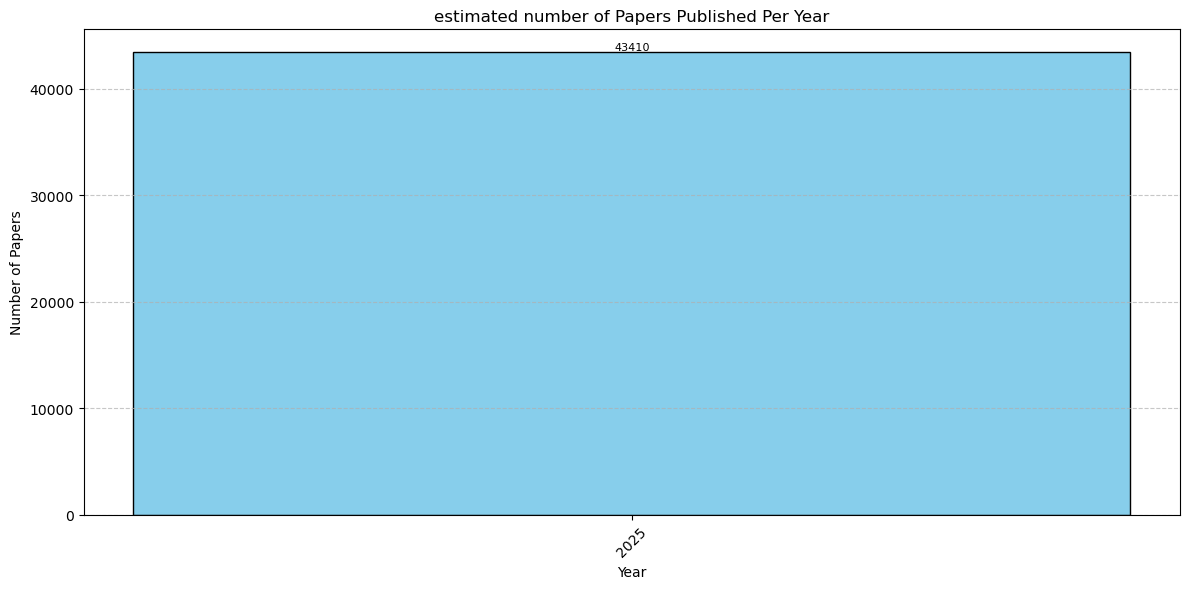

Fetching the list of PMIDs....
Total unique PMIDs fetched: 34819
Batch metadata summary:
  2025-01-01 to 2025-01-21: 6637 papers
  2025-01-22 to 2025-03-23: 9936 papers
  2025-03-24 to 2025-05-03: 7647 papers
  2025-05-04 to 2025-07-03: 9954 papers
  2025-07-04 to 2025-09-13: 9236 papers
PMID list saved to pmid_list_13_09_2025.txt


In [59]:
from datetime import datetime, timedelta, date
start_date = "2025-01-01"
stop_date = None  # Will default to the current date if None\
query_file = "query.txt"
pmid_list = fetch_pmids_over_period(query_file, start=start_date, stop=stop_date, full_text=False, plot=True)

In [4]:
with open('query.txt', 'w') as f:
    f.write(query)

In [58]:

# def get_pubmed_count(query, full_text=False):
#     # Remove trailing space from URL
#     url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi" 
#     db = "pmc" if full_text else "pubmed"
#     data = {
#         "db": db,
#         "term": query,
#         "retmax": 0, # We only want the count
#         "retmode": "json", # Use JSON for easier parsing
#         "api_key": API_KEY
#     }

#     # Basic rate limiting (consider improving if making many rapid calls)
#     rate_limit = 10 if API_KEY else 3
#     delay = 1 / rate_limit
#     time.sleep(delay) 

#     max_retries = 5
#     for attempt in range(max_retries):
#         try:
#             response = requests.post(url, data=data)
#             response.raise_for_status()
#             result = response.json()
#             # Safely get the count, defaulting to 0 if not found or not an integer string
#             count_str = result.get('esearchresult', {}).get('count', '0')
#             return int(count_str) if count_str.isdigit() else 0
#         except requests.exceptions.HTTPError as e:
#             if response.status_code == 429: # Rate limit exceeded
#                 wait_time = 2 ** attempt
#                 logging.warning(f"Rate limit hit (HTTP 429) for query '{query[:50]}...'. Retrying in {wait_time}s...")
#                 time.sleep(wait_time)
#                 continue
#             else:
#                 logging.error(f"HTTP error {response.status_code} for query '{query[:50]}...': {e}")
#                 break # Don't retry on other HTTP errors
#         except requests.exceptions.RequestException as e: # Catch other request issues (timeout, connection)
#              logging.error(f"Request error for query '{query[:50]}...': {e}")
#              break
#         except (KeyError, ValueError, TypeError) as e: # Handle JSON parsing issues or unexpected structure
#              logging.error(f"Error parsing response for query '{query[:50]}...': {e}")
#              break
#         except Exception as e:
#             logging.error(f"Unexpected error in get_pubmed_count for query '{query[:50]}...': {e}")
#             break # Don't retry on unexpected errors
#     logging.error(f"Failed to fetch PubMed count for query '{query[:200]}' after {max_retries} retries.")
#     return 0 # Return 0 on failure

from Bio import Entrez
import logging

# Ensure Entrez.email is set somewhere in your script before calling this function
# Entrez.email = "your_email@example.com"
# Optionally, set your API key globally for higher rate limits
# Entrez.api_key = "your_api_key"

def get_pubmed_count(query, full_text=False):
    """
    Fetches the estimated count of records matching a query using Entrez ESearch.

    Args:
        query (str): The search term.
        full_text (bool): If True, searches PMC database; otherwise, searches PubMed.

    Returns:
        int: The estimated count of matching records, or 0 on failure.
    """
    db = "pmc" if full_text else "pubmed"
    if not Entrez.email:
        Entrez.email = input("Enter your email for NCBI Entrez: ").strip()
    if not Entrez.api_key and API_KEY:
        Entrez.api_key = input("Enter your NCBI API key (or press Enter to skip): ").strip() or None

    try:
        # Perform the search with retmax=0 to only get the count.
        # Entrez.esearch automatically handles rate limiting and retries.
        handle = Entrez.esearch(db=db, term=query, retmax=0, retmode="xml")
        record = Entrez.read(handle)
        handle.close()

        # Extract the count from the parsed XML record.
        count_str = record.get("Count", "0")
        
        # Safely convert the count string to an integer.
        return int(count_str) if count_str.isdigit() else 0

    except Exception as e:
        # Log any unexpected errors during the process.
        logging.error(f"Error fetching count from Entrez for query '{query[:100]}...': {e}")
        return 0



def get_list(query, full_text=False, api_key=None):
    """Fetches a list of PMIDs matching a query using Entrez ESearch """
    db = "pmc" if full_text else "pubmed"
    # Ensure Entrez.email is set before calling
    if not Entrez.email:
        logging.error("Entrez.email must be set before calling get_list.")
        return []

    if api_key is None:
        api_key = API_KEY # Use global API_KEY if not passed
    start_index = 0
    pmids = []
    max_retries = 5
    retmax = 9999 
    try:
        # Use retmax=0 to just get the count and WebEnv info if needed later
        handle_count = Entrez.esearch(db=db, term=query, retmax=0, retmode="xml") # api_key included if set globally or passed
        record_count = Entrez.read(handle_count)
        handle_count.close()
        total_count_str = record_count.get("Count", "0")
        total_count = int(total_count_str) if total_count_str.isdigit() else 0

        # --- NEW ---
        # Respect the Entrez 10,000 record limit for esearch
        # ESearch can only retrieve the first 10,000 records matching the query.
        total_count = min(total_count, 9999)  # Cap at 9999 to avoid issues
        # --- END NEW ---

        if total_count == 0:
            logging.info(f"No records found for query: {query[:100]}...")
            return []
    except Exception as e:
        logging.error(f"Error getting record count for query '{query[:100]}...': {e}")
        return []

    # Main fetching loop
    start_index = 0
    pmids = []
    # Loop while haven't fetched all records up to the capped total_count
    while start_index < total_count: 
        # Determine how many records to fetch in this batch
        # Ensure we don't try to fetch more than total_count allows
        current_retmax = min(retmax, total_count - start_index)

        for attempt in range(max_retries):
            try:
                handle = Entrez.esearch(
                    db=db,  
                    term=query,
                    retstart=start_index,
                    retmax=current_retmax, # Use the calculated batch size
                    retmode="xml",
                    api_key=api_key # Pass if needed
                )
                record = Entrez.read(handle)
                handle.close()

                current_batch = record.get("IdList", [])
                batch_size = len(current_batch)
                
                # --- IMPROVED LOGIC ---
                if batch_size == 0:
                    # It's safer to log and potentially break to avoid infinite loops.
                    logging.warning(f"Received empty batch at start_index {start_index} (expected up to {current_retmax} more). Stopping fetch.")
                    break # Exit the retry loop and the while loop
                
                pmids.extend(current_batch)
                start_index += batch_size # Increment by actual batch size fetched
                
                logging.debug(f"Fetched batch: {batch_size} PMIDs (Total so far: {len(pmids)})")

                # --- TERMINATION CONDITION ---
                # Check if we have fetched all expected records 
                # (either we hit the 10k limit or the actual total)
                if len(pmids) >= total_count: 
                    logging.debug("Reached estimated total count. Fetching complete.")
                    break # Exit retry loop, condition will also exit while loop

                break # Success, exit retry loop for this batch

            except Exception as e:
                wait_time = 2 ** attempt
                logging.warning(f"Retrying fetch (attempt {attempt + 1}/{max_retries}) in {wait_time}s due to error: {e}")
                time.sleep(wait_time)
        else:
            # This block executes if the for loop completes without 'break' (all retries failed)
            logging.error(f"Failed to fetch PMIDs after {max_retries} retries for query '{query[:100]}...' at index {start_index}. Fetched {len(pmids)} so far.")
            # Break the main while loop to prevent getting stuck
            break
    return pmids


def get_fixed_month_interval(start_date):
    "for old dates of universal query"
    try:
        if start_date <= date.fromisoformat("1828-01-01"):
            return 564
        elif start_date <= date.fromisoformat("1843-01-01"):
            return 168
        elif start_date <= date.fromisoformat("1849-01-01"):
            return 72
        elif start_date <= date.fromisoformat("1854-01-01"):
            return 60
        elif start_date <= date.fromisoformat("1859-01-01"):
            return 59
        elif start_date <= date.fromisoformat("1865-01-01"):
            return 72
        else:
            return None
    except ValueError as e: # Handle potential invalid date strings if inputs are strings
        logging.error(f"Invalid date in get_fixed_month_interval: {e}")
        return None

def generate_date_batches(query, start_date, stop_date, target_papers_per_batch=10000, window_sizes=[365, 180, 90, 60, 40, 20, 10, 1], max_workers=2, full_text=False):
    """
    Generate date batches that are forced to stay within calendar years,
    but use adaptive windowing *within* each year to respect paper count limits.
    """

    print(f"Generating year-aligned batches with internal windowing from {start_date} to {stop_date}...\n")

    date_ranges = []
    total_papers = 0

    first_year = start_date.year
    last_year = stop_date.year

    def get_count_for_window(start, days):
        end = min(start + timedelta(days=days), stop_date)
        # Use consistent date formatting
        q = f'("{start.strftime("%Y/%m/%d")}"[PDat] : "{end.strftime("%Y/%m/%d")}"[PDat]) {query}'
        count = get_pubmed_count(q, full_text=full_text)
        return (start, end, count)

    for year in range(first_year, last_year + 1):
        year_start = date(year, 1, 1)
        year_end = date(year, 12, 31)

        batch_start = max(start_date, year_start)
        batch_end = min(stop_date, year_end)

        if batch_start > batch_end:
            continue

        current = batch_start

        while current <= batch_end:
            # Ensure candidates don't exceed batch_end
            candidates = [min(current + timedelta(days=w), batch_end) for w in window_sizes]

            results = []
            # Using ThreadPoolExecutor for parallel counting
            with ThreadPoolExecutor(max_workers=max_workers) as executor:
                futures = [
                    executor.submit(get_count_for_window, current, (end - current).days)
                    for end in candidates
                ]
                # Collect results as they complete
                for f in as_completed(futures):
                    try:
                        results.append(f.result())
                    except Exception as e:
                        logging.error(f"Error while evaluating date window in year {year}: {e}")

            best = None
            # Sort results by window size (descending) to try larger windows first
            for start, end, count in sorted(results, key=lambda x: (x[1] - x[0]).days, reverse=True):

                if count <= target_papers_per_batch:
                    best = (start, end, count)
                    total_papers += count
                    break # Found an acceptable window, break inner loop

            if best:
                date_ranges.append(best)
                # Move to the day after the end of the selected window
                current = best[1] + timedelta(days=1)
            else:
                # Fallback if no window meets the target (e.g., even 1 day > target)
                fallback_end = min(current + timedelta(days=1), batch_end)
                # Recalculate count for the fallback window
                fallback_query = f'("{current.strftime("%Y/%m/%d")}"[PDat] : "{fallback_end.strftime("%Y/%m/%d")}"[PDat]) {query}'
                count = get_pubmed_count(fallback_query, full_text=full_text)
                if count > target_papers_per_batch:
                    logging.warning(f"1-day batch from {current} contains {count} papers, exceeding {target_papers_per_batch} threshold.")
                total_papers += count
                date_ranges.append((current, fallback_end, count))
                current = fallback_end + timedelta(days=1) # Move to next day


    print(f"\n Total batches generated: {len(date_ranges)}")
    print(f"Estimated total papers across all batches margin is 30%: {total_papers}")

    return date_ranges # Returns list of (start_date, end_date, count) tuples


def fetch_pmids_parallel(date_batches, query, full_text, max_workers):
    """Fetches PMIDs for a list of date batches in parallel."""
    results = []
    metadata = []

    def fetch_single_batch(batch_tuple):
        """Fetches PMIDs for a single batch tuple (start_date, end_date, count)."""
        # Unpack the tuple correctly (assuming 3 elements now)
        start_date, end_date, _ = batch_tuple # We don't use the pre-calculated count here
        # Format dates consistently for the Entrez query
        date_query = f'("{start_date.strftime("%Y/%m/%d")}"[PDat] : "{end_date.strftime("%Y/%m/%d")}"[PDat])'
        full_query = f"{date_query} {query}"
        pmids = get_list(full_query, full_text) # This returns a list of PMIDs
        # Create metadata using the actual count of fetched PMIDs
        meta = {"start": start_date, "end": end_date, "count": len(pmids)}
        return pmids, meta

    # Use ThreadPoolExecutor for parallel fetching
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # Submit tasks for each batch
        future_to_batch = {executor.submit(fetch_single_batch, batch): batch for batch in date_batches}
        # Process completed tasks
        for future in as_completed(future_to_batch):
            batch = future_to_batch[future]
            try:
                # Get the result (pmids list and metadata dict)
                pmids, meta = future.result()
                results.extend(pmids) # Add PMIDs to the main list
                metadata.append(meta) # Add metadata to the list
            except Exception as e:
                # Log errors for individual batches
                logging.error(f"Failed to fetch PMIDs for batch {batch}: {e}")

    return results, metadata # Return combined list of PMIDs and list of metadata dicts


def read_query_from_file(filename):
    """Read and clean query from a file."""
    try:
        with open(filename, 'r', encoding='utf-8') as file: # Specify encoding
            query = file.read().strip() # Strip whitespace/newlines
        if not query:
             logging.warning(f"Query file {filename} is empty.")
        return query
    except FileNotFoundError:
        logging.error(f"Query file not found: {filename}")
        return None
    except Exception as e:
        logging.error(f"Error reading query file {filename}: {e}")
        return None

def plot_density_over_time(batch_metadata):
    """
    Plots the number of papers published per year based on batch metadata.
    Expects batch_metadata to be a list of dictionaries with keys 'start', 'end', 'count'.
    'start' and 'end' should be datetime.date objects.
    """
    import matplotlib.pyplot as plt
    from collections import defaultdict

    if not batch_metadata:
        print("No batch metadata to plot.")
        return

    # Dictionary to accumulate paper counts per year
    yearly_counts = defaultdict(int)

    # Iterate over the list of dictionaries
    for item in batch_metadata:
        try:
            start_date = item["start"]  # Access the date object
            count = item["count"]
            # Ensure start_date is a date object before accessing .year
            if isinstance(start_date, date):
                year = start_date.year
                yearly_counts[year] += count
            else:
                 logging.warning(f"Invalid start date type in metadata item: {item}")
        except KeyError as e:
             logging.error(f"Missing key in batch metadata item: {e} in {item}")
        except Exception as e:
             logging.error(f"Error processing batch metadata item {item}: {e}")

    if not yearly_counts:
        print("No valid yearly counts to plot.")
        return

    # Sort years for plotting
    years = sorted(yearly_counts.keys())
    counts = [yearly_counts[year] for year in years]

    # Create the plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(years, counts, color='skyblue', edgecolor='black')
    plt.title("estimated number of Papers Published Per Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Papers")
    plt.grid(axis='y', linestyle='--', alpha=0.7)


    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom', fontsize=8)

    plt.xticks(years, rotation=45)
    plt.tight_layout()
    plt.show()


def fetch_pmids_over_period(query_file, start="2000-01-01", stop=None, full_text=False, plot=True, max_workers=2):
    """Main function to orchestrate fetching PMIDs over a period."""
    global API_KEY
    if not getattr(Entrez, 'email', None): # Check if Entrez.email is set
         Entrez.email = input("Please enter your email for NCBI Entrez: ").strip()
         if not Entrez.email:
             logging.error("Entrez.email is required. Exiting.")
             return []
    # Get API Key
    if not API_KEY:
        api_input = input('Please enter NCBI API key *recommended* (or press Enter to skip): ').strip()
        API_KEY = api_input if api_input else None
        if API_KEY:
            Entrez.api_key = API_KEY # Set Entrez.api_key if using Biopython's Entrez
            logging.info("API key set for Entrez.")
        else:
            logging.warning("No API key provided. Rate limits may apply.")


    # Read query
    query = read_query_from_file(query_file)
    if not query:
        logging.error("Failed to read or invalid query.")
        return []

    # Parse dates
    try:
        start_date = date.fromisoformat(start)
        if stop is None:
            stop_date = date.today()
        else:
            stop_date = date.fromisoformat(stop)
    except ValueError as e:
        logging.error(f"Invalid date format: {e}")
        return []

    # Generate date batches
    print("Generating date batches...")
    date_batches = generate_date_batches(
        query=query,
        start_date=start_date,
        stop_date=stop_date,
        full_text=full_text,
        max_workers=max_workers,
    )

    # Plot if requested
    if plot and date_batches:
        # Prepare metadata for plotting (list of dicts)
        batch_metadata_preview = [
            {
                "start": start_date_obj,  # Keep as date object
                "end": end_date_obj,      # Keep as date object
                "count": count            # Use the precomputed count
            }
            for start_date_obj, end_date_obj, count in date_batches 
        ]
        print('Plotting the density of papers over time....')
        plot_density_over_time(batch_metadata_preview)
    elif plot:
        print("No batches generated, skipping plot.")

    # Fetch PMIDs in parallel
    print('Fetching the list of PMIDs....')
    if not date_batches:
        logging.warning("No date batches generated, returning empty list.")
        return []

    pmid_list, batch_metadata = fetch_pmids_parallel(
        date_batches=date_batches,
        query=query,
        full_text=full_text,
        max_workers=max_workers
    )

    # Remove duplicates from the final list
    unique_pmid_list = list(set(pmid_list))
    print(f'Total unique PMIDs fetched: {len(unique_pmid_list)}')

    # Print batch summary
    print('Batch metadata summary:')
    for meta in batch_metadata:
        print(f"  {meta['start']} to {meta['end']}: {meta['count']} papers")

    # Save PMIDs to file
    today_str = date.today().strftime("%d_%m_%Y")
    filename = f'pmid_list_{today_str}.txt'
    try:
        with open(filename, 'w') as file:
            for pmid in unique_pmid_list:
                file.write(f"{pmid}\n")
        print(f'PMID list saved to {filename}')
    except Exception as e:
        logging.error(f"Error saving PMIDs to file {filename}: {e}")

    return unique_pmid_list

# Example usage (if running this script directly):
# if __name__ == "__main__":
#     # Make sure query.txt exists
#     pmids = fetch_pmids_over_period("query.txt", start="2020-01-01", stop="2020-12-31", full_text=False, plot=True, max_workers=2)
#     print(f"Fetched {len(pmids)} unique PMIDs.")


In [ ]:
from Bio import Entrez
from Bio import Medline  # Correct import
import pandas as pd
from typing import List
from tqdm import tqdm
import time
import re
import logging

# Ensure Entrez.email and Entrez.api_key are set appropriately before calling functions
# Entrez.email = "your_email@example.com"
# Entrez.api_key = "your_actual_api_key" # Optional but recommended

def fetch_parse_pubmed_metadata(pmids: List[str]) -> pd.DataFrame:
    '''Fetch and parse PubMed records for a list of PMIDs using Biopython Entrez with epost for efficiency.'''
    records = []

    # Step 0: Validate Input and Configure Entrez
    if not getattr(Entrez, 'email', None):
        Entrez.email = input("Enter your email (required by NCBI): ").strip()
        if not Entrez.email:
            logging.error("Entrez.email is required. Cannot proceed.")
            # Optionally raise an exception or return empty DataFrame
            return pd.DataFrame()

    # Fix syntax error: Add colon
    if not getattr(Entrez, 'api_key', None):
        Entrez.api_key = "70faf5cc42501a814dcc4bdb1862acaf3909" # Ensure this is your actual key
        logging.info("NCBI API key set.")

    # Ensure all PMIDs are strings and remove empty/None values
    cleaned_pmids = [str(pmid) for pmid in pmids if pmid]
    unique_pmid_list = list(set(cleaned_pmids))

    if not unique_pmid_list:
        logging.warning("No valid PMIDs provided after cleaning. Returning empty DataFrame.")
        return pd.DataFrame()

    total_count = len(unique_pmid_list)
    logging.info(f"Processing {total_count} unique PMIDs.")

    # Step 1: Upload the list of PMIDs using epost
    webenv = None
    query_key = None
    try:
        # Join PMIDs into a comma-separated string
        pmid_string = ",".join(unique_pmid_list)
        if not pmid_string: # Double check after join
             raise ValueError("PMID string is empty after joining.")
        # Perform epost
        epost_handle = Entrez.epost(db="pubmed", id=pmid_string)
        epost_result = Entrez.read(epost_handle)
        epost_handle.close()

        webenv = epost_result["WebEnv"]
        query_key = epost_result["QueryKey"]
        logging.debug(f"epost successful. WebEnv: {webenv[:20]}..., QueryKey: {query_key}")

    except Exception as e:
        logging.error(f"Failed to upload PMIDs with epost: {e}")
        return pd.DataFrame() # Return empty DataFrame on epost failure

    # Step 2: Define batch size (Reduced from 2000 for safety)
    batch_size = 500
    logging.info(f"Fetching records in batches of {batch_size}.")

    # Step 3: Fetch and process records in batches
    for start in tqdm(range(0, total_count, batch_size), desc="Fetching PubMed batches"):
        end = min(total_count, start + batch_size)
        current_batch_size = end - start # Calculate actual size for this batch
        stream = None # Initialize stream variable

        try:
            logging.debug(f"Fetching batch: records {start} to {end-1} (size: {current_batch_size})")

            # Fetch the batch using the WebEnv session
            # No 'id' parameter needed when using webenv/query_key from epost
            stream = Entrez.efetch(
                db="pubmed",
                rettype="medline",        # Correct for Medline parser
                retmode="text",           # Correct for Medline parser
                retstart=start,           # Defines start index within the WebEnv result set
                retmax=current_batch_size, # Use actual size for this batch (fixes potential issue with last batch)
                webenv=webenv,            # Use the session from epost
                query_key=query_key,      # Use the query key from epost
            )

            # Parse the batch
            batch_iterator = Medline.parse(stream)

            for article in batch_iterator:
                # --- Extract and clean fields inline ---

                # PMID, PMCID, Title, Abstract, Authors
                pmid = article.get("PMID", "")
                pmcid = article.get("PMC", "")
                title = article.get("TI", "")
                abstract = article.get("AB", "")
                authors = "; ".join(article.get("AU", []))

                # --- DOI from AID (inline) ---
                doi = ""
                aid_list = article.get("AID", [])
                for aid in aid_list:
                    if "[doi]" in aid.lower(): # Case-insensitive check
                        doi = aid.split(" ")[0]  # Extract DOI part before ' [doi]'
                        break

                # --- Dates: Reformat YYYYMMDD → YYYY-MM-DD (inline) ---
                def reformat_ymd(date_str):
                    return f"{date_str[0:4]}-{date_str[4:6]}-{date_str[6:8]}" if date_str and len(date_str) == 8 and date_str.isdigit() else date_str

                date_completed = reformat_ymd(article.get("DCOM", ""))
                date_created = reformat_ymd(article.get("DA", ""))
                date_last_revised = reformat_ymd(article.get("LR", ""))
                date_publication = article.get("DP", "") # Keep as is, often not in YYYYMMDD

                # --- ISSN: Extract first xxxx-xxxx (inline) ---
                raw_issn = article.get("IS", "")
                issn_match = re.search(r"\d{4}-\d{4}", raw_issn)
                issn = issn_match.group(0) if issn_match else ""

                # Journal, Issue, Volume
                issue = article.get("IP", "")
                volume = article.get("VI", "")
                journal_abbrev = article.get("TA", "")
                journal_full = article.get("JT", "")

                # --- Combined Terms: MH + OT + RN (cleaned) + NM (inline) ---
                mesh_terms = article.get("MH", [])
                other_terms = article.get("OT", [])
                substance_names = article.get("NM", [])

                # Clean RN: extract text inside parentheses
                registry_numbers_cleaned = []
                for rn_entry in article.get("RN", []):
                    match = re.search(r"\(([^)]+)\)", rn_entry)
                    if match:
                        registry_numbers_cleaned.append(match.group(1))
                    else:
                        registry_numbers_cleaned.append(rn_entry)

                combined_terms = "; ".join(
                    list(mesh_terms) +
                    list(other_terms) +
                    list(registry_numbers_cleaned) +
                    list(substance_names)
                )

                # --- Build final record ---
                record = {
                    "PMID": pmid,
                    "PMCID": pmcid,
                    "Title": title,
                    "Abstract": abstract,
                    "Authors": authors,
                    "DOI": doi,
                    "Date Completed": date_completed,
                    "Date Created": date_created,
                    "Date Last Revised": date_last_revised,
                    "Date of Publication": date_publication,
                    "ISSN": issn,
                    "Issue": issue,
                    "Volume": volume,
                    "Journal Title Abbreviation": journal_abbrev,
                    "Journal Title": journal_full,
                    "Combined Terms (MH+OT+RN+NM)": combined_terms,
                }

                records.append(record)

        except Exception as e: # Catch errors from efetch, parsing, etc.
            logging.error(f"Error fetching or parsing batch starting at index {start} (PMIDs ~{unique_pmid_list[start:start+5]}...): {e}")
            # Decide: continue to next batch or stop? Continuing is often preferred.
            # raise # Uncomment to stop on first batch error
        finally:
            # Ensure the stream is closed if it was opened
            if stream is not None:
                try:
                    stream.close()
                    logging.debug(f"Stream for batch {start}-{end-1} closed.")
                except Exception as close_error:
                    logging.warning(f"Error closing stream for batch {start}-{end-1}: {close_error}")

        # Be polite to NCBI servers
        # Biopython handles basic rate limiting, this adds extra safety.
        # 0.34s -> ~3 req/s (without API key). With API key (10 req/s), 0.11s is theoretical min.
        time.sleep(0.34)

    logging.info(f"Finished fetching and parsing. Total records collected: {len(records)}")
    return pd.DataFrame(records)

# Example usage (ensure Entrez.email is set):
# pmids = ["12345678", "23456789", "12345678"] # Include a duplicate to test deduplication
# df = fetch_parse_pubmed_metadata(pmids)
# print(df.head())
# print(f"Shape: {df.shape}")
# print(f"Unique PMIDs in result: {df['PMID'].nunique()}")


In [72]:
df = fetch_parse_pubmed_metadata_CONCURRENT(pmid_list)

2025-09-13 13:31:14 littlebeauty root[1205747] INFO Divided 34819 PMIDs into 4 chunks of max 9999.
Processing PMID Chunks:   0%|          | 0/4 [00:00<?, ?chunk/s]

Processing PMID Chunks: 100%|██████████| 4/4 [01:24<00:00, 21.24s/chunk]
2025-09-13 13:32:39 littlebeauty root[1205747] INFO All chunks processed. Total records collected: 34819
